In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as DoanNhatKhoi
from collections import deque

In [22]:
img = cv.imread('hinh1.jpg', 0) # ảnh xám cho Thresholding
img_color = cv.imread('hinh1.jpg') # ảnh màu cho K-means
img_color = cv.cvtColor(img_color, cv.COLOR_BGR2RGB) # chuyển kênh màu từ bgr sang rgb

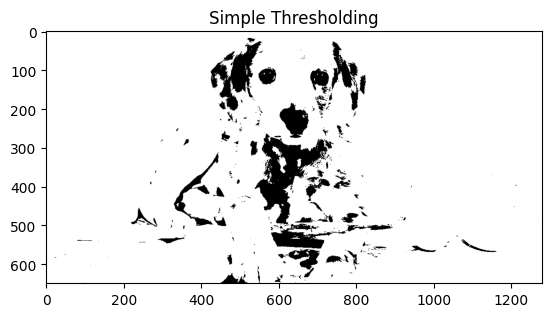

In [ ]:
# set ngưỡng thresh là 127
ret, thresh1 = cv.threshold(img, 127, 255, cv.THRESH_BINARY)

DoanNhatKhoi.imshow(thresh1, cmap='gray')
DoanNhatKhoi.title('Simple Thresholding')
DoanNhatKhoi.show()

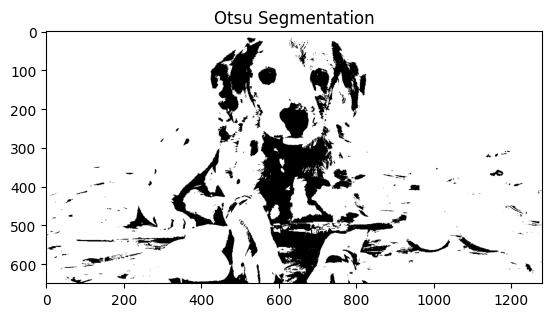

In [ ]:
# dùng Otsu's thresholding để tự động tìm ngưỡng tốt nhất
ret2, th2 = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

DoanNhatKhoi.imshow(th2, cmap='gray')
DoanNhatKhoi.title('Otsu Segmentation')
DoanNhatKhoi.show()

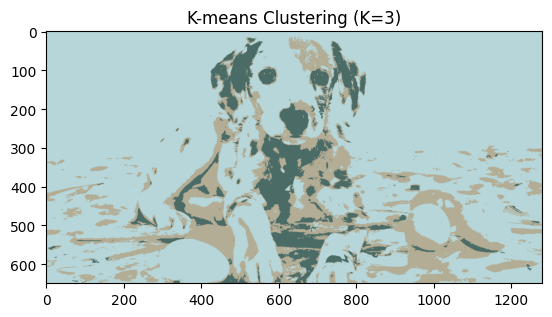

In [ ]:
# chuyển đổi ảnh màu thành một mảng 2D với 3 kênh màu (R, G, B)
pixel_values = img_color.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# áp dụng thuật toán K-means để phân cụm màu sắc trong ảnh
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3
_, labels, centers = cv.kmeans(pixel_values, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# chuyển đổi các giá trị trung tâm màu sắc thành kiểu uint8 và tạo ảnh phân cụm
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape((img_color.shape))

DoanNhatKhoi.imshow(segmented_image)
DoanNhatKhoi.title(f'K-means Clustering (K={K})')
DoanNhatKhoi.show()

In [26]:
# hàm kiểm tra độ đồng nhất của một vùng dựa trên độ lệch chuẩn
def is_homogeneous(region, threshold):
    # dùng độ lệch chuẩn
    # nếu std thấp, vùng đó có màu sắc tương đối đồng đều
    return np.std(region) <= threshold

In [27]:
# hàm đệ quy thực hiện bước chia vùng cho thuật toán QuadTree
def split(img, x, y, w, h, threshold):
    region = img[y:y+h, x:x+w] # trích xuất vùng con từ ảnh gốc dựa trên tọa độ và kích thước

    # đặt điều kiện dừng: Vùng đồng nhất hoặc kích thước quá nhỏ (vd: 4x4 pixel)
    if is_homogeneous(region, threshold) or w <= 4 or h <= 4:
        # trả về tọa độ và giá trị màu trung bình
        return [(x, y, w, h, np.mean(region))]

    # nếu không đồng nhất, chia làm 4 vùng con
    w_half, h_half = w // 2, h // 2

    regions = []
    # gọi đệ quy cho 4 phần tử của 4 vùng con
    regions.extend(split(img, x, y, w_half, h_half, threshold))
    regions.extend(split(img, x + w_half, y, w - w_half, h_half, threshold))
    regions.extend(split(img, x, y + h_half, w_half, h - h_half, threshold))
    regions.extend(split(img, x + w_half, y + h_half, w - w_half, h - h_half, threshold))

    return regions

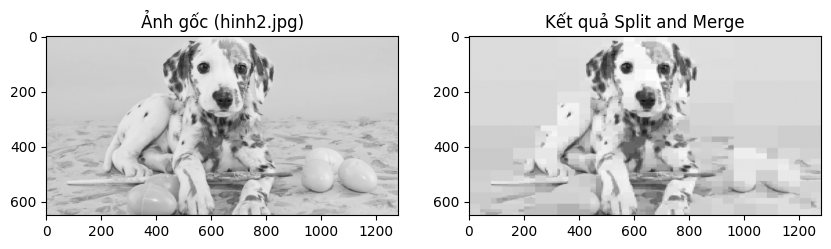

In [ ]:
h, w = img.shape
threshold_val = 15 # ngưỡng để xác định độ đồng nhất của vùng 

# thực hiện thuật toán chia vùng đệ quy
all_regions = split(img, 0, 0, w, h, threshold_val)

# tạo một ảnh kết quả để hiển thị các vùng đã được chia và gán giá trị màu trung bình cho mỗi vùng
result_img = np.zeros_like(img)
for (rx, ry, rw, rh, r_mean) in all_regions:
    result_img[ry:ry+rh, rx:rx+rw] = int(r_mean)

# hiện thị ảnh gốc và ảnh kết quả
DoanNhatKhoi.figure(figsize=(10, 5))
DoanNhatKhoi.subplot(1, 2, 1)
DoanNhatKhoi.imshow(img, cmap='gray')
DoanNhatKhoi.title('Ảnh gốc (hinh2.jpg)')

DoanNhatKhoi.subplot(1, 2, 2)
DoanNhatKhoi.imshow(result_img, cmap='gray')
DoanNhatKhoi.title('Kết quả Split and Merge')

DoanNhatKhoi.show()

In [29]:
def region_growing_optimized(img, seed, thresh=30): # hàm tối ưu, đặt ngưỡng mặc định là 30
    rows, cols = img.shape  # lấy kích thước ảnh
    segmented = np.zeros_like(img)  # tạo ảnh đen với kích thước bằng ảnh gốc để lưu kết quả 

    # sử dụng deque để làm hàng đợi cho thuật toán lan truyền vùng
    queue = deque([seed])

    # lấy giá trị cường độ sáng của pixel giống gốc để so sánh với các pixel lân cận
    seed_val = int(img[seed[0], seed[1]])

    # đánh dấu pixel giống gốc là đã được duyệt (tô trắng) để tránh lặp lại
    segmented[seed[0], seed[1]] = 255

    while len(queue) > 0:   # trong khi hàng đợi vẫn còn 
        x, y = queue.popleft() # lấy tạo độ của pixel hiện tại từ hàng đợi

        # duyệt 4 điểm trên dưới trái phải
        for i, j in [(-1,0), (1,0), (0,-1), (0,1)]:
            nx, ny = x + i, y + j   # tính toán tọa độ của pixel lân cận

            # kiểm tra nếu các điểm lân cận nằm trong phạm vi ảnh
            if 0 <= nx < rows and 0 <= ny < cols:
                # nếu chưa pixel chưa đc tô trắng thì sẽ được coi là chưa được duyệt và đưa vào hàng đợi
                if segmented[nx, ny] == 0:
                    # và so giá trị với các pixel lân cận
                    if abs(int(img[nx, ny]) - seed_val) < thresh: # nếu sự khác biệt nhỏ hơn ngưỡng, coi như cùng vùng
                        segmented[nx, ny] = 255 # tô trắng pixel
                        queue.append((nx, ny))  # thêm vào hàng hàng đợi 

    return segmented    # trả về ảnh đã được phân đoạn sau khi lan truyền vùng hoàn tất

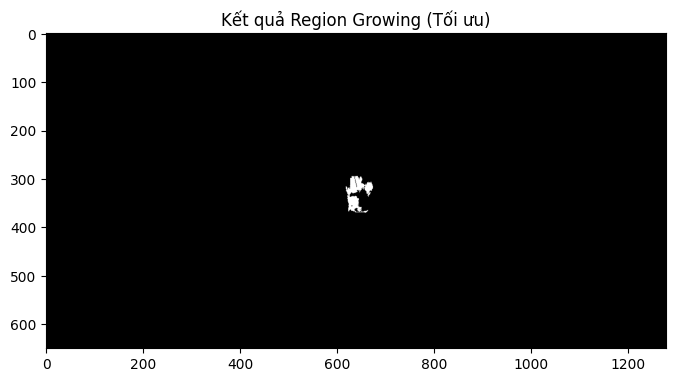

In [ ]:
# lấy tọa độ điểm chính giữa của ảnh.
seed_point = (img.shape[0]//2, img.shape[1]//2)

# gọi hàm tối ưu đã tạo ở trên
rg_result = region_growing_optimized(img, seed_point, thresh=35)

# hiển thị kết quả
DoanNhatKhoi.figure(figsize=(8, 6))
DoanNhatKhoi.imshow(rg_result, cmap='gray')
DoanNhatKhoi.title('Kết quả Region Growing (Tối ưu)')
DoanNhatKhoi.show()

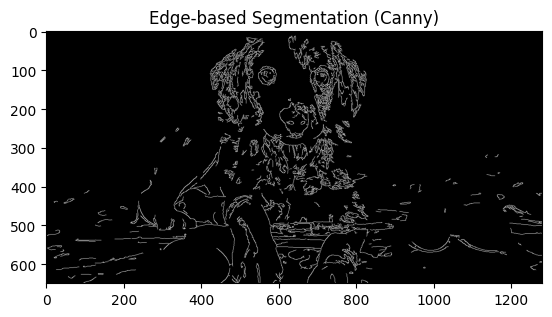

In [ ]:
# sử dụng Canny để phát hiện biên của đối tượng trong ảnh
edges = cv.Canny(img, 100, 200)

DoanNhatKhoi.imshow(edges, cmap='gray')
DoanNhatKhoi.title('Edge-based Segmentation (Canny)')
DoanNhatKhoi.show()